# 04 — Build Strict and Relaxed Modelling Datasets

This notebook creates two defensible versions of the cleaned daily dataset before any models are trained.

## Dataset variants

### Strict dataset

A session is retained only when:

- it contains exactly 390 regular-session SPY minute bars;
- SPX has exact observations at 14:59 and 15:59 ET;
- no SPX observations are missing during 13:00–14:59 ET;
- no VIX observations are missing during 13:00–14:59 ET.

### Relaxed dataset

A session is retained when:

- it contains exactly 390 regular-session SPY minute bars;
- SPX has exact observations at 14:59 and 15:59 ET;
- no SPX observations are missing during 13:00–14:59 ET;
- no more than five VIX observations are missing during 13:00–14:59 ET;
- valid backward-matched VIX observations, no more than 120 seconds old, exist at the endpoints needed for the 15-, 30- and 60-minute VIX-return features.

The relaxed rule permits isolated VIX publication gaps but still excludes materially incomplete sessions.

## Fair-comparison rule

Both variants use the **same calendar dates** for training, validation and testing. The date boundaries are derived from the strict dataset and then applied unchanged to the relaxed dataset.

No imputation, clipping, scaling, feature selection or model fitting is performed here.

## 1. Environment and project discovery

This notebook expects the outputs produced by the EDA and cleaning notebooks.

In [2]:
from pathlib import Path
import json
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
VARIANT_ROOT = OUTPUT_ROOT / "dataset_variants"
FIGURE_ROOT = VARIANT_ROOT / "figures"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
VARIANT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Variant outputs:", VARIANT_ROOT)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Database: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\market.duckdb
Variant outputs: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants


## 2. Load the aligned and daily datasets

In [3]:
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
DAILY_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"


def load_parquet_or_table(path: Path, table_name: str) -> pd.DataFrame:
    if path.exists():
        print("Loading:", path)
        return pd.read_parquet(path)

    available_tables = set(
        con.execute(
            """
            SELECT table_name
            FROM information_schema.tables
            """
        ).df()["table_name"]
    )

    if table_name in available_tables:
        print("Loading DuckDB table:", table_name)
        return con.execute(
            f"SELECT * FROM {table_name}"
        ).df()

    raise FileNotFoundError(
        f"Neither {path} nor DuckDB table {table_name} exists."
    )


aligned = load_parquet_or_table(
    ALIGNED_PATH,
    "aligned_underlyings_1min",
)

daily_model = load_parquet_or_table(
    DAILY_PATH,
    "daily_underlying_model_dataset",
)

aligned["timestamp_utc"] = pd.to_datetime(
    aligned["timestamp_utc"],
    utc=True,
)
aligned["timestamp_et"] = pd.to_datetime(
    aligned["timestamp_et"],
)
aligned["session_date"] = aligned["session_date"].astype(str)

for column in ["spx_timestamp_utc", "vix_timestamp_utc"]:
    if column in aligned.columns:
        aligned[column] = pd.to_datetime(
            aligned[column],
            utc=True,
        )

daily_model["session_date"] = pd.to_datetime(
    daily_model["session_date"],
)

if "feature_cutoff_timestamp_utc" in daily_model.columns:
    daily_model["feature_cutoff_timestamp_utc"] = pd.to_datetime(
        daily_model["feature_cutoff_timestamp_utc"],
        utc=True,
    )

aligned = (
    aligned.drop_duplicates(
        ["session_date", "timestamp_utc"],
        keep="last",
    )
    .sort_values(
        ["session_date", "timestamp_utc"]
    )
    .reset_index(drop=True)
)

daily_model = (
    daily_model.drop_duplicates(
        ["session_date"],
        keep="last",
    )
    .sort_values("session_date")
    .reset_index(drop=True)
)

numeric_columns = daily_model.select_dtypes(
    include=[np.number]
).columns

daily_model[numeric_columns] = daily_model[
    numeric_columns
].replace([np.inf, -np.inf], np.nan)

if "clock_minute" not in aligned.columns:
    aligned["clock_minute"] = (
        aligned["timestamp_et"].dt.hour * 60
        + aligned["timestamp_et"].dt.minute
    )

print("Aligned minute rows:", len(aligned))
print("Aligned sessions:", aligned["session_date"].nunique())
print("Daily rows:", len(daily_model))

Loading: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\aligned_underlyings_1min.parquet
Loading: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset.parquet
Aligned minute rows: 194495
Aligned sessions: 501
Daily rows: 496


## 3. Construct the session-quality audit

The VIX feature endpoints are:

- 13:59 for the 60-minute starting value;
- 14:29 for the 30-minute starting value;
- 14:44 for the 15-minute starting value;
- 14:59 for the common ending value.

At each endpoint, the matched VIX value must come from the same timestamp or an earlier timestamp no more than 120 seconds old.

In [4]:
FULL_SESSION_ROWS = 390
MAX_RELAXED_VIX_GAPS = 5
MAX_VIX_STALENESS_SECONDS = 120

VIX_REQUIRED_ANCHORS = {
    "vix_1359_valid": 13 * 60 + 59,
    "vix_1429_valid": 14 * 60 + 29,
    "vix_1444_valid": 14 * 60 + 44,
    "vix_1459_valid": 14 * 60 + 59,
}


def exact_spx_anchor(
    group: pd.DataFrame,
    minute_of_day: int,
) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]

    if anchor.empty:
        return False

    exact_match = anchor["spx_timestamp_utc"].eq(
        anchor["timestamp_utc"]
    )

    return bool(
        anchor["spx_close"].notna().any()
        and exact_match.any()
    )


def valid_vix_anchor(
    group: pd.DataFrame,
    minute_of_day: int,
) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]

    if anchor.empty:
        return False

    valid_rows = anchor[
        anchor["vix_close"].notna()
        & anchor["vix_timestamp_utc"].notna()
    ].copy()

    if valid_rows.empty:
        return False

    staleness = (
        valid_rows["timestamp_utc"]
        - valid_rows["vix_timestamp_utc"]
    ).dt.total_seconds()

    return bool(
        staleness.ge(0).all()
        and staleness.le(
            MAX_VIX_STALENESS_SECONDS
        ).all()
    )


quality_rows = []

for session_date, group in aligned.groupby("session_date"):
    group = group.sort_values("timestamp_utc")

    final_120m = group[
        group["clock_minute"].between(
            13 * 60,
            14 * 60 + 59,
        )
    ]

    row = {
        "session_date": session_date,
        "rows": len(group),
        "first_time_et": (
            group["timestamp_et"]
            .min()
            .strftime("%H:%M:%S")
        ),
        "last_time_et": (
            group["timestamp_et"]
            .max()
            .strftime("%H:%M:%S")
        ),
        "exact_spx_1459": exact_spx_anchor(
            group,
            14 * 60 + 59,
        ),
        "exact_spx_1559": exact_spx_anchor(
            group,
            15 * 60 + 59,
        ),
        "missing_spx_final_120m": int(
            final_120m["spx_close"].isna().sum()
        ),
        "missing_vix_final_120m": int(
            final_120m["vix_close"].isna().sum()
        ),
        "max_vix_staleness_final_120m": (
            final_120m["vix_staleness_seconds"].max()
        ),
    }

    for column_name, minute_of_day in VIX_REQUIRED_ANCHORS.items():
        row[column_name] = valid_vix_anchor(
            group,
            minute_of_day,
        )

    quality_rows.append(row)

session_quality = pd.DataFrame(quality_rows)

session_quality["strict_eligible"] = (
    session_quality["rows"].eq(FULL_SESSION_ROWS)
    & session_quality["exact_spx_1459"]
    & session_quality["exact_spx_1559"]
    & session_quality["missing_spx_final_120m"].eq(0)
    & session_quality["missing_vix_final_120m"].eq(0)
)

required_vix_columns = list(
    VIX_REQUIRED_ANCHORS.keys()
)

session_quality["relaxed_eligible"] = (
    session_quality["rows"].eq(FULL_SESSION_ROWS)
    & session_quality["exact_spx_1459"]
    & session_quality["exact_spx_1559"]
    & session_quality["missing_spx_final_120m"].eq(0)
    & session_quality["missing_vix_final_120m"].le(
        MAX_RELAXED_VIX_GAPS
    )
    & session_quality[
        required_vix_columns
    ].all(axis=1)
)

assert not (
    session_quality["strict_eligible"]
    & ~session_quality["relaxed_eligible"]
).any(), (
    "Every strict session should also satisfy the relaxed rule."
)

display(
    session_quality[
        [
            "strict_eligible",
            "relaxed_eligible",
        ]
    ]
    .value_counts()
    .rename("sessions")
    .reset_index()
)

SESSION_QUALITY_PATH = (
    VARIANT_ROOT
    / "strict_relaxed_session_quality.csv"
)

session_quality.to_csv(
    SESSION_QUALITY_PATH,
    index=False,
)

print("Saved:", SESSION_QUALITY_PATH)

,strict_eligible,relaxed_eligible,sessions
0,True,True,434
1,False,True,52
2,False,False,15


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\strict_relaxed_session_quality.csv


## 4. Explain exclusion reasons

This table makes every inclusion and exclusion reproducible.

In [5]:
def strict_exclusion_reason(row) -> str:
    reasons = []

    if row["rows"] != FULL_SESSION_ROWS:
        reasons.append(
            f"session length {int(row['rows'])}"
        )

    if not row["exact_spx_1459"]:
        reasons.append("no exact SPX 14:59")

    if not row["exact_spx_1559"]:
        reasons.append("no exact SPX 15:59")

    if row["missing_spx_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_spx_final_120m'])} "
            "missing SPX observations in final 120m"
        )

    if row["missing_vix_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_vix_final_120m'])} "
            "missing VIX observations in final 120m"
        )

    return "; ".join(reasons) if reasons else "eligible"


def relaxed_exclusion_reason(row) -> str:
    reasons = []

    if row["rows"] != FULL_SESSION_ROWS:
        reasons.append(
            f"session length {int(row['rows'])}"
        )

    if not row["exact_spx_1459"]:
        reasons.append("no exact SPX 14:59")

    if not row["exact_spx_1559"]:
        reasons.append("no exact SPX 15:59")

    if row["missing_spx_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_spx_final_120m'])} "
            "missing SPX observations in final 120m"
        )

    if (
        row["missing_vix_final_120m"]
        > MAX_RELAXED_VIX_GAPS
    ):
        reasons.append(
            f"{int(row['missing_vix_final_120m'])} "
            "missing VIX observations exceeds relaxed limit"
        )

    invalid_anchors = [
        column
        for column in required_vix_columns
        if not bool(row[column])
    ]

    if invalid_anchors:
        reasons.append(
            "invalid VIX feature endpoints: "
            + ", ".join(invalid_anchors)
        )

    return "; ".join(reasons) if reasons else "eligible"


session_quality["strict_reason"] = session_quality.apply(
    strict_exclusion_reason,
    axis=1,
)

session_quality["relaxed_reason"] = session_quality.apply(
    relaxed_exclusion_reason,
    axis=1,
)

relaxed_only_sessions = session_quality[
    session_quality["relaxed_eligible"]
    & ~session_quality["strict_eligible"]
].copy()

excluded_from_both = session_quality[
    ~session_quality["relaxed_eligible"]
].copy()

print("Relaxed-only sessions:", len(relaxed_only_sessions))
display(
    relaxed_only_sessions[
        [
            "session_date",
            "missing_vix_final_120m",
            "max_vix_staleness_final_120m",
            *required_vix_columns,
            "strict_reason",
        ]
    ].sort_values("session_date")
)

print("Excluded from both variants:", len(excluded_from_both))
display(
    excluded_from_both[
        [
            "session_date",
            "rows",
            "missing_spx_final_120m",
            "missing_vix_final_120m",
            "exact_spx_1459",
            "exact_spx_1559",
            "relaxed_reason",
        ]
    ].sort_values("session_date")
)

RELAXED_ONLY_PATH = (
    VARIANT_ROOT
    / "relaxed_only_sessions.csv"
)

EXCLUDED_BOTH_PATH = (
    VARIANT_ROOT
    / "excluded_from_both_variants.csv"
)

relaxed_only_sessions.to_csv(
    RELAXED_ONLY_PATH,
    index=False,
)

excluded_from_both.to_csv(
    EXCLUDED_BOTH_PATH,
    index=False,
)

print("Saved:", RELAXED_ONLY_PATH)
print("Saved:", EXCLUDED_BOTH_PATH)

Relaxed-only sessions: 52


,session_date,missing_vix_final_120m,max_vix_staleness_final_120m,vix_1359_valid,vix_1429_valid,vix_1444_valid,vix_1459_valid,strict_reason
22,2024-08-19,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
61,2024-10-14,4,120.000000,True,True,True,True,4 missing VIX observations in final 120m
67,2024-10-22,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
80,2024-11-08,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
83,2024-11-13,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
92,2024-11-26,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
95,2024-12-02,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
97,2024-12-04,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
101,2024-12-10,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
102,2024-12-11,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m


Excluded from both variants: 15


,session_date,rows,missing_spx_final_120m,missing_vix_final_120m,exact_spx_1459,exact_spx_1559,relaxed_reason
25,2024-08-22,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
81,2024-11-11,390,0,2,True,True,invalid VIX feature endpoints: vix_1444_valid
94,2024-11-29,211,0,0,False,False,session length 211; no exact SPX 14:59; no exa...
111,2024-12-24,211,0,0,False,False,session length 211; no exact SPX 14:59; no exa...
240,2025-07-03,211,0,0,False,False,session length 211; no exact SPX 14:59; no exa...
244,2025-07-10,390,0,10,True,True,10 missing VIX observations exceeds relaxed limit
249,2025-07-17,390,0,3,True,True,invalid VIX feature endpoints: vix_1444_valid
251,2025-07-21,390,0,6,True,True,6 missing VIX observations exceeds relaxed limit
254,2025-07-24,390,0,1,True,True,invalid VIX feature endpoints: vix_1459_valid
302,2025-10-01,390,0,1,True,True,invalid VIX feature endpoints: vix_1359_valid


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\relaxed_only_sessions.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\excluded_from_both_variants.csv


## 5. Build the two daily datasets

Both datasets:

- remove missing and non-finite targets;
- remove exact zero-return sessions from the binary target;
- use `target_up = 1` for Up and `target_up = 0` for Down;
- retain the original untransformed feature values.

In [6]:
def build_variant(
    source: pd.DataFrame,
    eligible_dates: set[str],
    variant_name: str,
) -> pd.DataFrame:
    frame = source[
        source["session_date"]
        .dt.strftime("%Y-%m-%d")
        .isin(eligible_dates)
    ].copy()

    frame = frame[
        frame["final_hour_return"].notna()
    ].copy()

    frame = frame[
        np.isfinite(
            frame["final_hour_return"]
        )
    ].copy()

    frame = frame[
        ~frame["final_hour_return"].eq(0)
    ].copy()

    frame["target_up"] = (
        frame["final_hour_return"] > 0
    ).astype("int8")

    frame["final_hour_direction_binary"] = np.where(
        frame["target_up"].eq(1),
        "Up",
        "Down",
    )

    frame["dataset_variant"] = variant_name

    return (
        frame.sort_values("session_date")
        .reset_index(drop=True)
    )


strict_dates = set(
    session_quality.loc[
        session_quality["strict_eligible"],
        "session_date",
    ]
)

relaxed_dates = set(
    session_quality.loc[
        session_quality["relaxed_eligible"],
        "session_date",
    ]
)

strict_dataset = build_variant(
    daily_model,
    strict_dates,
    "strict",
)

relaxed_dataset = build_variant(
    daily_model,
    relaxed_dates,
    "relaxed",
)

strict_session_dates = set(
    strict_dataset["session_date"]
)

relaxed_session_dates = set(
    relaxed_dataset["session_date"]
)

assert strict_session_dates.issubset(
    relaxed_session_dates
)

variant_summary = pd.DataFrame(
    [
        {
            "dataset_variant": "strict",
            "rows": len(strict_dataset),
            "first_date": strict_dataset["session_date"].min(),
            "last_date": strict_dataset["session_date"].max(),
            "up_sessions": int(
                strict_dataset["target_up"].sum()
            ),
            "down_sessions": int(
                strict_dataset["target_up"].eq(0).sum()
            ),
        },
        {
            "dataset_variant": "relaxed",
            "rows": len(relaxed_dataset),
            "first_date": relaxed_dataset["session_date"].min(),
            "last_date": relaxed_dataset["session_date"].max(),
            "up_sessions": int(
                relaxed_dataset["target_up"].sum()
            ),
            "down_sessions": int(
                relaxed_dataset["target_up"].eq(0).sum()
            ),
        },
    ]
)

variant_summary["additional_rows_vs_strict"] = (
    variant_summary["rows"]
    - len(strict_dataset)
)

display(variant_summary)

STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed.parquet"
)

strict_dataset.to_parquet(
    STRICT_PATH,
    index=False,
)

relaxed_dataset.to_parquet(
    RELAXED_PATH,
    index=False,
)

VARIANT_SUMMARY_PATH = (
    VARIANT_ROOT
    / "variant_summary.csv"
)

variant_summary.to_csv(
    VARIANT_SUMMARY_PATH,
    index=False,
)

print("Saved:", STRICT_PATH)
print("Saved:", RELAXED_PATH)
print("Saved:", VARIANT_SUMMARY_PATH)

,dataset_variant,rows,first_date,last_date,up_sessions,down_sessions,additional_rows_vs_strict
0,strict,434,2024-07-18,2026-07-17,216,218,0
1,relaxed,486,2024-07-18,2026-07-17,240,246,52


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_strict.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_relaxed.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\variant_summary.csv


## 6. Compare target balance and missingness

A relaxed dataset should add observations without creating new missing daily feature values.

,dataset_variant,rows,feature_missing_values,up_pct,down_pct,mean_final_hour_return,final_hour_return_std
0,strict,434,0,49.769585,50.230415,-0.000033,0.003098
1,relaxed,486,0,49.382716,50.617284,-0.000021,0.002964


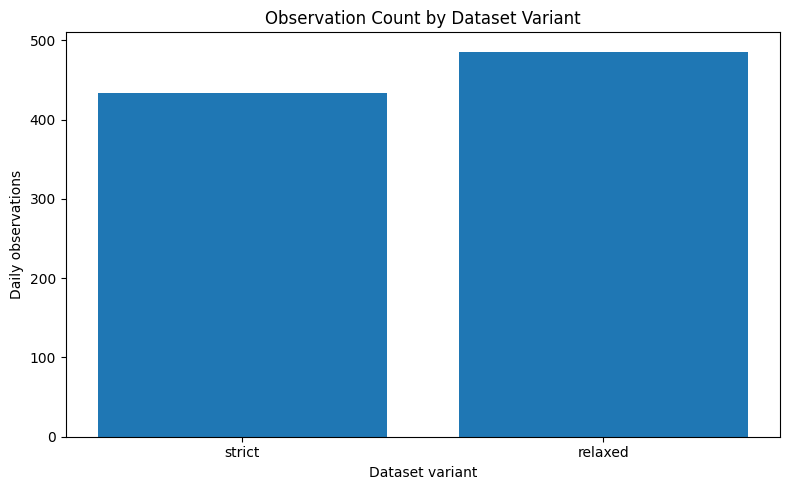

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\variant_target_and_missingness_comparison.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\figures\strict_relaxed_observation_counts.png


In [ ]:
identifier_columns = {
    "session_date",
    "feature_cutoff_timestamp_utc",
    "final_hour_direction",
    "final_hour_direction_binary",
    "target_up",
    "day_of_week", 
    "month",
    "dataset_variant",
}

target_columns = {
    "final_hour_return",
    "spx_at_close",
}

feature_columns = [
    column
    for column in strict_dataset.columns
    if column not in identifier_columns
    and column not in target_columns
    and pd.api.types.is_numeric_dtype(
        strict_dataset[column]
    )
]

comparison_rows = []

for name, frame in [
    ("strict", strict_dataset),
    ("relaxed", relaxed_dataset),
]:
    comparison_rows.append(
        {
            "dataset_variant": name,
            "rows": len(frame),
            "feature_missing_values": int(
                frame[feature_columns]
                .isna()
                .sum()
                .sum()
            ),
            "up_pct": float(
                frame["target_up"].mean() * 100
            ),
            "down_pct": float(
                frame["target_up"].eq(0).mean() * 100
            ),
            "mean_final_hour_return": float(
                frame["final_hour_return"].mean()
            ),
            "final_hour_return_std": float(
                frame["final_hour_return"].std()
            ),
        }
    )

variant_comparison = pd.DataFrame(
    comparison_rows
)

display(variant_comparison)

VARIANT_COMPARISON_PATH = (
    VARIANT_ROOT
    / "variant_target_and_missingness_comparison.csv"
)

variant_comparison.to_csv(
    VARIANT_COMPARISON_PATH,
    index=False,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    variant_summary["dataset_variant"],
    variant_summary["rows"],
)
ax.set_title("Observation Count by Dataset Variant")
ax.set_xlabel("Dataset variant")
ax.set_ylabel("Daily observations")
figure_path = save_figure(
    fig,
    "strict_relaxed_observation_counts.png",
)
plt.show()

print("Saved:", VARIANT_COMPARISON_PATH)
print("Saved:", figure_path)

## 7. Create common chronological split boundaries

The strict dataset determines the calendar cutoffs. Those exact dates are then applied to both variants.

This prevents the relaxed dataset from receiving later training or validation dates merely because it contains more observations.

In [8]:
TRAIN_PROPORTION = 0.70
VALIDATION_PROPORTION = 0.15

strict_sorted = strict_dataset.sort_values(
    "session_date"
).reset_index(drop=True)

strict_rows = len(strict_sorted)

strict_train_end = int(
    np.floor(
        strict_rows * TRAIN_PROPORTION
    )
)

strict_validation_end = int(
    np.floor(
        strict_rows
        * (
            TRAIN_PROPORTION
            + VALIDATION_PROPORTION
        )
    )
)

if (
    strict_train_end < 1
    or strict_validation_end <= strict_train_end
    or strict_validation_end >= strict_rows
):
    raise RuntimeError(
        "The strict dataset is too small for the requested split."
    )

TRAIN_END_DATE = strict_sorted.loc[
    strict_train_end - 1,
    "session_date",
]

VALIDATION_END_DATE = strict_sorted.loc[
    strict_validation_end - 1,
    "session_date",
]

print("Common train end date:", TRAIN_END_DATE.date())
print(
    "Common validation end date:",
    VALIDATION_END_DATE.date(),
)


def apply_common_split(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    result = frame.copy()

    result["data_split"] = np.select(
        [
            result["session_date"].le(
                TRAIN_END_DATE
            ),
            result["session_date"].le(
                VALIDATION_END_DATE
            ),
        ],
        [
            "Train",
            "Validation",
        ],
        default="Test",
    )

    return result


strict_split = apply_common_split(
    strict_dataset
)

relaxed_split = apply_common_split(
    relaxed_dataset
)

split_rows = []

for variant_name, frame in [
    ("strict", strict_split),
    ("relaxed", relaxed_split),
]:
    for split_name in [
        "Train",
        "Validation",
        "Test",
    ]:
        subset = frame[
            frame["data_split"].eq(
                split_name
            )
        ]

        split_rows.append(
            {
                "dataset_variant": variant_name,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": (
                    subset["session_date"].min()
                    if len(subset)
                    else pd.NaT
                ),
                "last_date": (
                    subset["session_date"].max()
                    if len(subset)
                    else pd.NaT
                ),
                "up_sessions": int(
                    subset["target_up"].sum()
                ),
                "down_sessions": int(
                    subset["target_up"].eq(0).sum()
                ),
                "mean_final_hour_return": (
                    subset["final_hour_return"].mean()
                ),
                "final_hour_return_std": (
                    subset["final_hour_return"].std()
                ),
            }
        )

split_summary = pd.DataFrame(split_rows)

display(split_summary)

for frame in [strict_split, relaxed_split]:
    assert (
        frame.loc[
            frame["data_split"].eq("Train"),
            "session_date",
        ].max()
        <
        frame.loc[
            frame["data_split"].eq("Validation"),
            "session_date",
        ].min()
    )

    assert (
        frame.loc[
            frame["data_split"].eq("Validation"),
            "session_date",
        ].max()
        <
        frame.loc[
            frame["data_split"].eq("Test"),
            "session_date",
        ].min()
    )

STRICT_SPLIT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_SPLIT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

SPLIT_SUMMARY_PATH = (
    VARIANT_ROOT
    / "common_calendar_split_summary.csv"
)

strict_split.to_parquet(
    STRICT_SPLIT_PATH,
    index=False,
)

relaxed_split.to_parquet(
    RELAXED_SPLIT_PATH,
    index=False,
)

split_summary.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False,
)

print("Saved:", STRICT_SPLIT_PATH)
print("Saved:", RELAXED_SPLIT_PATH)
print("Saved:", SPLIT_SUMMARY_PATH)

Common train end date: 2025-12-03
Common validation end date: 2026-03-20


,dataset_variant,data_split,sessions,first_date,last_date,up_sessions,down_sessions,mean_final_hour_return,final_hour_return_std
0,strict,Train,303,2024-07-18,2025-12-03,147,156,-0.000080,0.003307
1,strict,Validation,65,2025-12-04,2026-03-20,29,36,-0.000024,0.002761
2,strict,Test,66,2026-03-23,2026-07-17,40,26,0.000172,0.002354
3,relaxed,Train,334,2024-07-18,2025-12-03,158,176,-0.000076,0.003179
4,relaxed,Validation,71,2025-12-04,2026-03-20,32,39,-0.000062,0.002648
5,relaxed,Test,81,2026-03-23,2026-07-17,50,31,0.000239,0.002229


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_strict_split.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_relaxed_split.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\dataset_variants\common_calendar_split_summary.csv


## 8. Verify look-ahead safety and feature completeness

Both datasets must preserve the 14:59 ET feature cutoff and the original target formula.

In [9]:
def verify_variant(
    frame: pd.DataFrame,
    variant_name: str,
) -> None:
    assert not frame.duplicated(
        ["session_date"]
    ).any()

    if "feature_cutoff_timestamp_utc" in frame.columns:
        cutoff_et = (
            frame["feature_cutoff_timestamp_utc"]
            .dt.tz_convert(
                "America/New_York"
            )
            .dt.strftime("%H:%M:%S")
        )

        assert set(cutoff_et) == {
            "14:59:00"
        }

    target_check = np.isclose(
        frame["final_hour_return"],
        (
            frame["spx_at_close"]
            / frame["spx_at_1500"]
            - 1
        ),
    )

    assert target_check.all()

    missing_features = int(
        frame[feature_columns]
        .isna()
        .sum()
        .sum()
    )

    non_finite_features = int(
        (
            ~np.isfinite(
                frame[feature_columns]
                .to_numpy(dtype=float)
            )
        ).sum()
    )

    print(
        variant_name,
        {
            "rows": len(frame),
            "missing_features": missing_features,
            "non_finite_features": non_finite_features,
        },
    )

    assert missing_features == 0
    assert non_finite_features == 0


verify_variant(
    strict_split,
    "strict",
)

verify_variant(
    relaxed_split,
    "relaxed",
)

print("All variant checks passed.")

strict {'rows': 434, 'missing_features': 0, 'non_finite_features': 0}
relaxed {'rows': 486, 'missing_features': 0, 'non_finite_features': 0}
All variant checks passed.


## 9. Export the variant manifest

The manifest freezes the two eligibility rules and common split boundaries before modelling begins.

In [10]:
variant_manifest = {
    "strict_rule": {
        "regular_session_rows": FULL_SESSION_ROWS,
        "exact_spx_1459": True,
        "exact_spx_1559": True,
        "maximum_missing_spx_final_120m": 0,
        "maximum_missing_vix_final_120m": 0,
    },
    "relaxed_rule": {
        "regular_session_rows": FULL_SESSION_ROWS,
        "exact_spx_1459": True,
        "exact_spx_1559": True,
        "maximum_missing_spx_final_120m": 0,
        "maximum_missing_vix_final_120m": (
            MAX_RELAXED_VIX_GAPS
        ),
        "required_vix_anchor_times_et": [
            "13:59:00",
            "14:29:00",
            "14:44:00",
            "14:59:00",
        ],
        "maximum_vix_anchor_staleness_seconds": (
            MAX_VIX_STALENESS_SECONDS
        ),
    },
    "target": (
        "Binary Up/Down based on sign of "
        "14:59-to-15:59 SPX return"
    ),
    "common_split_dates": {
        "train_end_date": (
            TRAIN_END_DATE.strftime("%Y-%m-%d")
        ),
        "validation_end_date": (
            VALIDATION_END_DATE.strftime("%Y-%m-%d")
        ),
        "test_start_date": (
            (
                VALIDATION_END_DATE
                + pd.Timedelta(days=1)
            ).strftime("%Y-%m-%d")
        ),
    },
    "strict_rows": int(
        len(strict_split)
    ),
    "relaxed_rows": int(
        len(relaxed_split)
    ),
    "relaxed_additional_rows": int(
        len(relaxed_split)
        - len(strict_split)
    ),
    "preprocessing_applied": False,
    "strict_split_path": str(
        STRICT_SPLIT_PATH
    ),
    "relaxed_split_path": str(
        RELAXED_SPLIT_PATH
    ),
}

MANIFEST_PATH = (
    VARIANT_ROOT
    / "dataset_variant_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        variant_manifest,
        manifest_file,
        indent=2,
    )

print(
    json.dumps(
        variant_manifest,
        indent=2,
    )
)

print("Saved:", MANIFEST_PATH)

{
  "strict_rule": {
    "regular_session_rows": 390,
    "exact_spx_1459": true,
    "exact_spx_1559": true,
    "maximum_missing_spx_final_120m": 0,
    "maximum_missing_vix_final_120m": 0
  },
  "relaxed_rule": {
    "regular_session_rows": 390,
    "exact_spx_1459": true,
    "exact_spx_1559": true,
    "maximum_missing_spx_final_120m": 0,
    "maximum_missing_vix_final_120m": 5,
    "required_vix_anchor_times_et": [
      "13:59:00",
      "14:29:00",
      "14:44:00",
      "14:59:00"
    ],
    "maximum_vix_anchor_staleness_seconds": 120
  },
  "target": "Binary Up/Down based on sign of 14:59-to-15:59 SPX return",
  "common_split_dates": {
    "train_end_date": "2025-12-03",
    "validation_end_date": "2026-03-20",
    "test_start_date": "2026-03-21"
  },
  "strict_rows": 434,
  "relaxed_rows": 486,
  "relaxed_additional_rows": 52,
  "preprocessing_applied": false,
  "strict_split_path": "C:\\Users\\hkhat\\OneDrive\\Desktop\\Project\\Dissertation\\data\\derived\\daily_underlying

## 10. Final decision before modelling

The next notebook should be:

```text
05_underlying_baseline_models.ipynb
```

It should run the **same models, features, preprocessing pipeline, cross-validation procedure and probability threshold** on both dataset variants.

The preferred dataset variant must be chosen using training and validation results only. The test period must not determine whether the strict or relaxed cleaning rule is selected.

Recommended comparison criteria:

- expanding-window validation accuracy and balanced accuracy;
- ROC-AUC and log loss;
- stability across validation folds;
- calibration;
- coefficient or feature-importance stability;
- sensitivity of conclusions to the added relaxed sessions.

If the relaxed dataset improves sample size without materially reducing validation stability, it can become the primary dataset and the strict sample can serve as a robustness check. If the relaxed observations weaken results substantially or create unstable estimates, the strict sample should remain primary.

In [11]:
output_summary = pd.DataFrame(
    {
        "artifact": [
            "Strict dataset",
            "Relaxed dataset",
            "Strict split dataset",
            "Relaxed split dataset",
            "Session quality audit",
            "Relaxed-only sessions",
            "Excluded-from-both sessions",
            "Common split summary",
            "Variant manifest",
        ],
        "path": [
            str(STRICT_PATH),
            str(RELAXED_PATH),
            str(STRICT_SPLIT_PATH),
            str(RELAXED_SPLIT_PATH),
            str(SESSION_QUALITY_PATH),
            str(RELAXED_ONLY_PATH),
            str(EXCLUDED_BOTH_PATH),
            str(SPLIT_SUMMARY_PATH),
            str(MANIFEST_PATH),
        ],
    }
)

display(output_summary)

print(
    "Strict and relaxed datasets created successfully."
)

,artifact,path
0,Strict dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,Relaxed dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,Strict split dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,Relaxed split dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,Session quality audit,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,Relaxed-only sessions,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,Excluded-from-both sessions,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,Common split summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Variant manifest,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


Strict and relaxed datasets created successfully.
